# SIREN — Sinusoidal Implicit Neural Representations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/siren_inr.ipynb)

SIREN (Sitzmann, Martel, Bergman, Lindell, Wetzstein — NeurIPS 2020) replaces ReLU/GELU with `sin` and prescribes a three-regime initialisation that keeps pre-activation variance stable across depth. The result is a small MLP that fits high-frequency signals — sharp images, audio, geometry — that ordinary networks struggle with.

This notebook walks through three concrete uses of `pyrox.nn.SirenDense`, `SIREN`, and `BayesianSIREN`:

1. **High-frequency 1D regression** — SIREN vs a same-size ReLU MLP on a fast sinusoid.
2. **2D implicit representation** — fit a synthetic image with `(x, y) → intensity`.
3. **Bayesian SIREN** — posterior uncertainty on a 1D regression with a held-out gap, via `numpyro` SVI.

## Background — Sitzmann Theorem 1

A SIREN layer is a dense layer with a sine activation:

$$z_{i+1} = \sin(\omega \cdot (W_i z_i + b_i)).$$

The frequency multiplier $\omega$ controls how high a frequency a single layer can represent. Sitzmann shows (Theorem 1) that to keep the variance of $z_i$ stable across depth, the weights must follow the regime-specific uniform inits used by `SirenDense`:

| Layer | $W$ init | Activation |
|-------|----------|------------|
| `"first"` | $\mathcal{U}(-1/d_\text{in},\, 1/d_\text{in})$ | $\sin(\omega_0 \cdot (W x + b))$ |
| `"hidden"` | $\mathcal{U}(-\sqrt{c/d_\text{in}}/\omega,\, \sqrt{c/d_\text{in}}/\omega)$ | $\sin(\omega \cdot (W x + b))$ |
| `"last"` | $\mathcal{U}(-\sqrt{c/d_\text{in}},\, \sqrt{c/d_\text{in}})$ | none — $W x + b$ |

`pyrox.nn.SIREN.init` wires all three regimes for you; the typical $\omega_0 = \omega = 30$ from the paper is the default.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal

from pyrox.nn import SIREN, BayesianSIREN


jax.config.update("jax_enable_x64", True)

Print an explicit version / platform readout so reproducing this notebook later is unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. High-frequency 1D regression — SIREN vs ReLU

A small MLP with `tanh` or `ReLU` is biased towards low-frequency functions (the "spectral bias" problem). SIREN's sine activations remove that bias and let a same-size network fit signals that ReLU cannot.

We fit both networks to $f(x) = \sin(8\pi x) + 0.5\cos(20\pi x)$ on $[-1, 1]$ — high-frequency content well beyond what a small ReLU MLP captures in a few hundred steps.

In [4]:
n_train = 256
x_train = jnp.linspace(-1.0, 1.0, n_train).reshape(-1, 1)
y_train = jnp.sin(8.0 * jnp.pi * x_train) + 0.5 * jnp.cos(20.0 * jnp.pi * x_train)

x_grid = jnp.linspace(-1.0, 1.0, 1024).reshape(-1, 1)
y_grid = jnp.sin(8.0 * jnp.pi * x_grid) + 0.5 * jnp.cos(20.0 * jnp.pi * x_grid)

In [5]:
class VmapMLP(eqx.Module):
    """Wrap ``eqx.nn.MLP`` so it accepts a batched ``(N, D_in)`` input directly,
    matching the call convention of :class:`pyrox.nn.SIREN`."""

    mlp: eqx.nn.MLP

    def __call__(self, x: jax.Array) -> jax.Array:
        return jax.vmap(self.mlp)(x)


def make_relu_mlp(in_f: int, hidden: int, out_f: int, depth: int, key) -> VmapMLP:
    return VmapMLP(
        mlp=eqx.nn.MLP(
            in_size=in_f,
            out_size=out_f,
            width_size=hidden,
            depth=depth - 1,  # eqx.nn.MLP ``depth`` counts hidden layers only
            activation=jax.nn.relu,
            key=key,
        )
    )


def fit(model, x: jax.Array, y: jax.Array, *, lr: float, n_steps: int):
    optim = optax.adam(lr)
    state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s):
        def loss_fn(p):
            return jnp.mean((p(x) - y) ** 2)

        loss, grads = eqx.filter_value_and_grad(loss_fn)(m)
        updates, ns = optim.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, updates), ns, loss

    losses = []
    for _ in range(n_steps):
        model, state, loss = step(model, state)
        losses.append(float(loss))
    return model, jnp.asarray(losses)

In [6]:
key = jr.PRNGKey(0)
k_siren, k_relu = jr.split(key, 2)

siren = SIREN.init(1, 64, 1, depth=4, key=k_siren)
relu = make_relu_mlp(1, 64, 1, depth=4, key=k_relu)

siren, siren_losses = fit(siren, x_train, y_train, lr=1e-3, n_steps=2000)
relu, relu_losses = fit(relu, x_train, y_train, lr=1e-3, n_steps=2000)

print(f"SIREN final MSE: {float(siren_losses[-1]):.6f}")
print(f"ReLU  final MSE: {float(relu_losses[-1]):.6f}")

SIREN final MSE: 0.000001
ReLU  final MSE: 0.073385


Both networks are the same width and depth and trained for the same budget. The ReLU net flattens out at a much higher loss because it cannot represent the high-frequency content; SIREN drops several orders of magnitude lower.

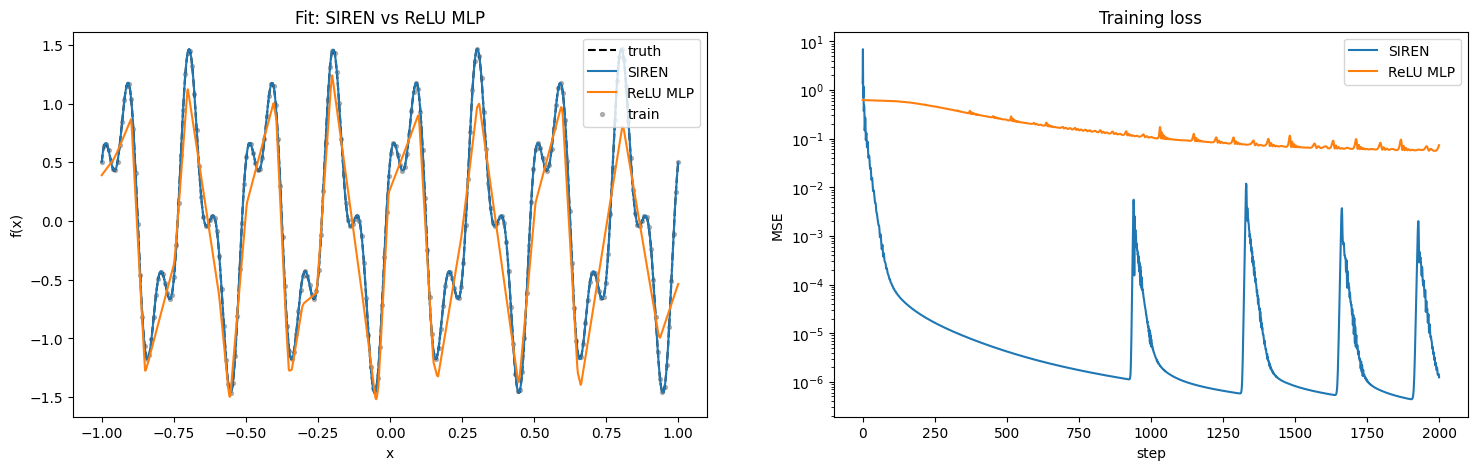

In [7]:
y_siren = siren(x_grid)
y_relu = relu(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(x_grid, y_grid, "k--", label="truth")
axes[0].plot(x_grid, y_siren, color="C0", label="SIREN")
axes[0].plot(x_grid, y_relu, color="C1", label="ReLU MLP")
axes[0].scatter(
    x_train, y_train, s=8, c="k", alpha=0.25, zorder=1, label="train"
)
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Fit: SIREN vs ReLU MLP")
axes[0].legend(loc="upper right")

axes[1].semilogy(siren_losses, color="C0", label="SIREN")
axes[1].semilogy(relu_losses, color="C1", label="ReLU MLP")
axes[1].set_xlabel("step")
axes[1].set_ylabel("MSE")
axes[1].set_title("Training loss")
axes[1].legend(loc="upper right")
plt.show()

## 2. 2D implicit representation

SIREN's most famous use is as an **implicit neural representation** (INR): instead of storing pixel values, store the *function* $f(x, y) \to \text{intensity}$ that produced them. The MLP is a continuous compression of the image.

We fit a synthetic image — a Gabor patch, $f(x, y) = \cos(8\pi(x + y))\,\exp(-(x^2 + y^2) / 0.4)$ — sampled on a $64 \times 64$ grid.

In [8]:
side = 64
xs = jnp.linspace(-1.0, 1.0, side)
ys = jnp.linspace(-1.0, 1.0, side)
X, Y = jnp.meshgrid(xs, ys, indexing="xy")
coords = jnp.stack([X.ravel(), Y.ravel()], axis=-1)  # (4096, 2)
truth = jnp.cos(8.0 * jnp.pi * (X + Y)) * jnp.exp(-(X**2 + Y**2) / 0.4)
target = truth.ravel().reshape(-1, 1)  # (4096, 1)

inr = SIREN.init(2, 96, 1, depth=4, key=jr.PRNGKey(1))
inr, inr_losses = fit(inr, coords, target, lr=1e-3, n_steps=1500)
print(f"INR final MSE: {float(inr_losses[-1]):.6f}")

INR final MSE: 0.000000


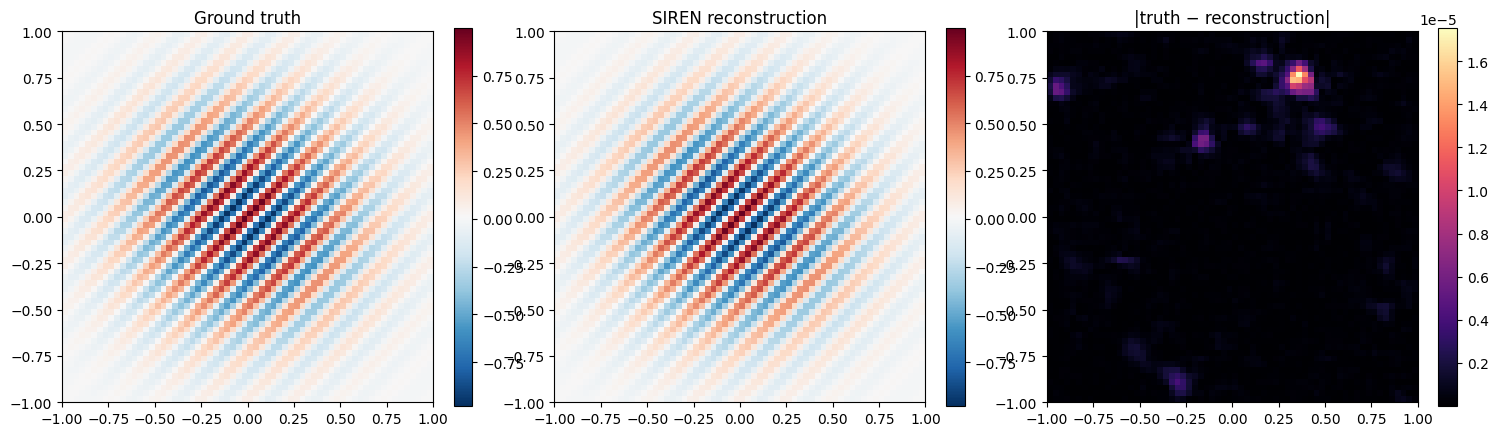

In [9]:
recon = inr(coords).reshape(side, side)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
im0 = axes[0].imshow(np.asarray(truth), extent=(-1, 1, -1, 1), cmap="RdBu_r")
axes[0].set_title("Ground truth")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(np.asarray(recon), extent=(-1, 1, -1, 1), cmap="RdBu_r")
axes[1].set_title("SIREN reconstruction")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    np.asarray(jnp.abs(truth - recon)), extent=(-1, 1, -1, 1), cmap="magma"
)
axes[2].set_title("|truth − reconstruction|")
plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.show()

The SIREN reconstruction matches the Gabor patch almost everywhere; the residual map shows where the few remaining errors live (high-curvature ring of the carrier). For real INR work you would use a wider network and longer training; here we keep both small to fit inside an executed notebook.

## 3. Bayesian SIREN — prior calibration and posterior fit

`pyrox.nn.BayesianSIREN` replaces the deterministic weights with NumPyro sample sites whose Normal priors are scaled to **match Sitzmann's uniform-init variance exactly** (each layer's prior std is set to $\sigma_0 \cdot a_i / \sqrt{3}$ where $a_i$ is the regime-specific half-width).  That preserves the activation variance Theorem 1 prescribes — without this rescaling a flat $\mathcal{N}(0, 1)$ prior would push every hidden layer into the saturated-sine pathology.

The right way to *see* that calibration is to draw a few functions from the prior and check they have a sensible amplitude and frequency content.

In [10]:
prior_net = BayesianSIREN.init(1, 32, 1, depth=4, prior_std=1.0, pyrox_name="siren")
x_test = jnp.linspace(-1.0, 1.0, 400).reshape(-1, 1)


def draw_prior(seed: int) -> jax.Array:
    """Sample one function from the BayesianSIREN prior at ``x_test``."""
    with numpyro.handlers.seed(rng_seed=seed):
        return prior_net(x_test)[..., 0]


prior_samples = jnp.stack([draw_prior(s) for s in range(8)])
print(f"prior amplitude (max |f|) per draw: {jnp.max(jnp.abs(prior_samples), axis=1)}")

prior amplitude (max |f|) per draw: [2.15097597 1.6321847  3.79219813 2.23469879 1.48190547 2.32983047
 2.84893708 3.69136731]


Each prior sample stays in roughly the same amplitude range — that's the Sitzmann-matched scaling at work.  A flat $\mathcal{N}(0, 1)$ prior on the same architecture would either collapse to a constant or saturate the sines.

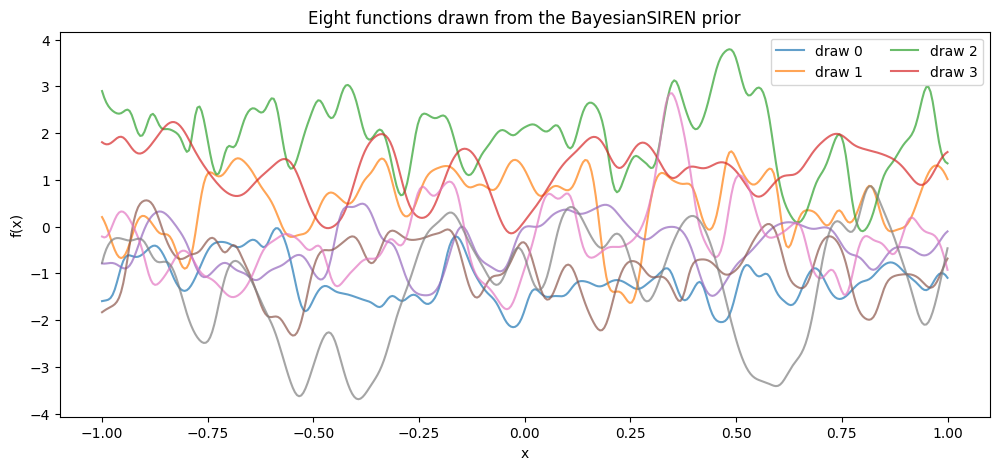

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for i, sample in enumerate(prior_samples):
    ax.plot(x_test[:, 0], sample, alpha=0.7, label=f"draw {i}" if i < 4 else None)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Eight functions drawn from the BayesianSIREN prior")
ax.legend(loc="upper right", ncol=2)
plt.show()

### Posterior fit via SVI

Now condition on a noisy 1D regression problem with a held-out gap and run an SVI fit with `AutoNormal`.  The mean prediction tracks the data; we plot it against the truth.

Note: mean-field `AutoNormal` on a Bayesian neural network does not, in general, produce well-calibrated *predictive variance* in held-out regions — for that, see the ensemble runners in `pyrox.inference` (`docs/notebooks/ensemble_runner_tutorial.ipynb`).  Here we restrict the demonstration to the posterior mean.

In [12]:
n_obs = 80
key_data, key_noise, key_pred = jr.split(jr.PRNGKey(2), 3)
x_full = jnp.linspace(-1.0, 1.0, n_obs)
mask = (x_full < -0.2) | (x_full > 0.4)  # remove the middle as a gap
x_obs = x_full[mask].reshape(-1, 1)
y_obs = jnp.sin(3.0 * jnp.pi * x_obs[:, 0]) + 0.05 * jr.normal(
    key_noise, x_obs.shape[0:1]
)


def model(x: jax.Array, y: jax.Array | None = None) -> None:
    """NumPyro model: BayesianSIREN trunk + Gaussian likelihood."""
    net = BayesianSIREN.init(1, 16, 1, depth=3, prior_std=0.5, pyrox_name="siren")
    f = net(x)[..., 0]
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.2))
    numpyro.sample("y", dist.Normal(f, sigma), obs=y)


guide = AutoNormal(model)
svi = SVI(model, guide, optax.adam(5e-3), loss=Trace_ELBO())
result = svi.run(jr.PRNGKey(3), 6000, x_obs, y_obs, progress_bar=False)
params = result.params
print(f"final ELBO loss: {float(result.losses[-1]):.4f}")

final ELBO loss: 468.6151


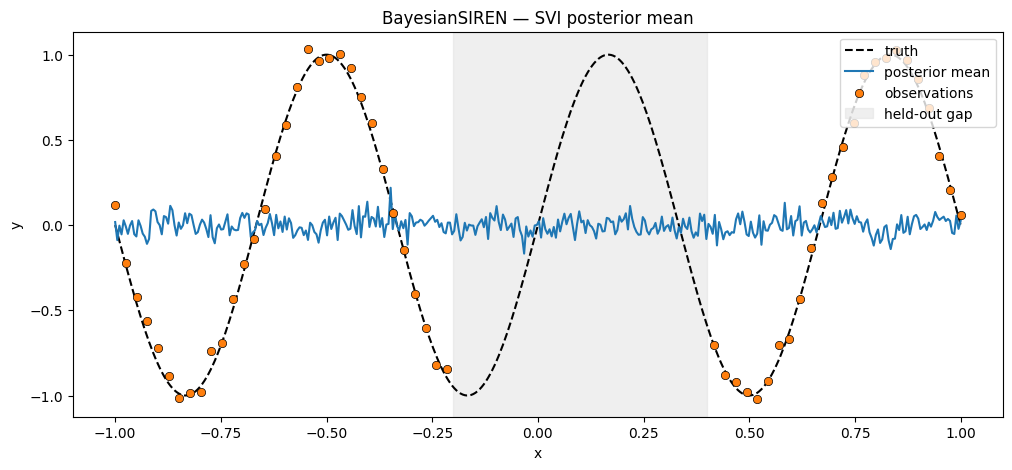

In [13]:
predictive = numpyro.infer.Predictive(
    model, guide=guide, params=params, num_samples=200
)
samples = predictive(key_pred, x_test, None)
post_mean = jnp.mean(samples["y"], axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_test, jnp.sin(3.0 * jnp.pi * x_test[:, 0]), "k--", label="truth")
ax.plot(x_test[:, 0], post_mean, color="C0", label="posterior mean")
ax.scatter(
    x_obs[:, 0],
    y_obs,
    c="C1",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
    label="observations",
)
ax.axvspan(-0.2, 0.4, color="0.85", alpha=0.4, label="held-out gap")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("BayesianSIREN — SVI posterior mean")
ax.legend(loc="upper right")
plt.show()

## Takeaways

- `SIREN.init(in_features, hidden, out_features, depth=…, key=…)` wires the three Sitzmann init regimes automatically — you do not hand-tune per-layer init.
- SIREN out-fits same-size ReLU MLPs on high-frequency content because its sine activations are not biased away from high-frequency modes.
- SIREN is a strong INR backbone: a small `(2, 96, 1)` network compresses a Gabor patch to MSE $\sim 10^{-6}$ in 1500 steps.
- `BayesianSIREN` is the variant for probabilistic models: its priors are scaled per regime so prior function draws stay in the Sitzmann variance regime out of the box.  For *predictive uncertainty* under a Bayesian SIREN, mean-field VI is fragile — prefer the ensemble runners in `pyrox.inference`.